# SCRIPT DE APRENDIZAJE: ESTADÍSTICA DE CÚMULOS ESTELARES EN R

## 1. CARGA DE DATOS (Creación de un vector)
En R, usamos c() para combinar valores individuales en un solo "vector".


In [4]:
edades <- c(
  9.7,  7.7,  7.4,  9.7,  7.8, 11.8,  8.2,
 11.3,  8.7,  6.8,  5.9,  7.2,  7.3,  6.3,
  9.0,  7.9,  6.3,  7.6, 10.7,  6.5,  7.0,
  8.1,  6.8,  7.0,  7.8,  7.7, 11.6
)

# Imprimir los datos y contar cuántos elementos hay
print("Datos cargados:")
print(edades)
cat("Número total de cúmulos estudiados (n):", length(edades), "\n\n")

[1] "Datos cargados:"
 [1]  9.7  7.7  7.4  9.7  7.8 11.8  8.2 11.3  8.7  6.8  5.9  7.2  7.3  6.3  9.0
[16]  7.9  6.3  7.6 10.7  6.5  7.0  8.1  6.8  7.0  7.8  7.7 11.6
Número total de cúmulos estudiados (n): 27 



## 2. RESOLVIENDO LAS PREGUNTAS DEL TALLER

In [5]:
print("--- RESULTADOS ESTADÍSTICOS ---")

# a) Estimador para el valor medio (Media Muestral)
media_edad <- mean(edades)
cat("a) Media muestral (Estimador del valor medio):", round(media_edad, 4), "Gyr\n")

# b) Valor que separa al 50% (Mediana Muestral)
mediana_edad <- median(edades)
cat("b) Mediana muestral (Separa el 50% inferior del 50% superior):", round(mediana_edad, 4), "Gyr\n")

# c) Desviación estándar poblacional (Estimada mediante la muestral sd)
desviacion_std <- sd(edades)
cat("c) Desviación estándar muestral:", round(desviacion_std, 4), "Gyr\n")

[1] "--- RESULTADOS ESTADÍSTICOS ---"
a) Media muestral (Estimador del valor medio): 8.1407 Gyr
b) Mediana muestral (Separa el 50% inferior del 50% superior): 7.7 Gyr
c) Desviación estándar muestral: 1.6595 Gyr


En R, evaluar una condición lógica (edades > 10) genera un vector de TRUE y FALSE.
Al aplicar mean(), R convierte TRUE en 1 y FALSE en 0, calculando la proporción exacta.

In [6]:
# d) Proporción de cúmulos cuya edad excede los 10 Gyr
proporcion_mayor_10 <- mean(edades > 10)
cat("d) Proporción de cúmulos con edad > 10 Gyr:", round(proporcion_mayor_10, 4), 
    "(o un", proporcion_mayor_10 * 100, "%)\n")

# e) Coeficiente de variación (Desviación estándar / Media)
coef_variacion <- desviacion_std / media_edad
cat("e) Coeficiente de variación (sd / mean):", round(coef_variacion, 4), "\n\n")

d) Proporción de cúmulos con edad > 10 Gyr: 0.1481 (o un 14.81481 %)
e) Coeficiente de variación (sd / mean): 0.2039 



## 3. CREACIÓN DE GRÁFICOS ESTADÍSTICOS
Configurar Jupyter para mostrar dos gráficos lado a lado (1 fila, 2 columnas)

In [7]:
options(repr.plot.width = 12, repr.plot.height = 5)
par(mfrow = c(1, 2))

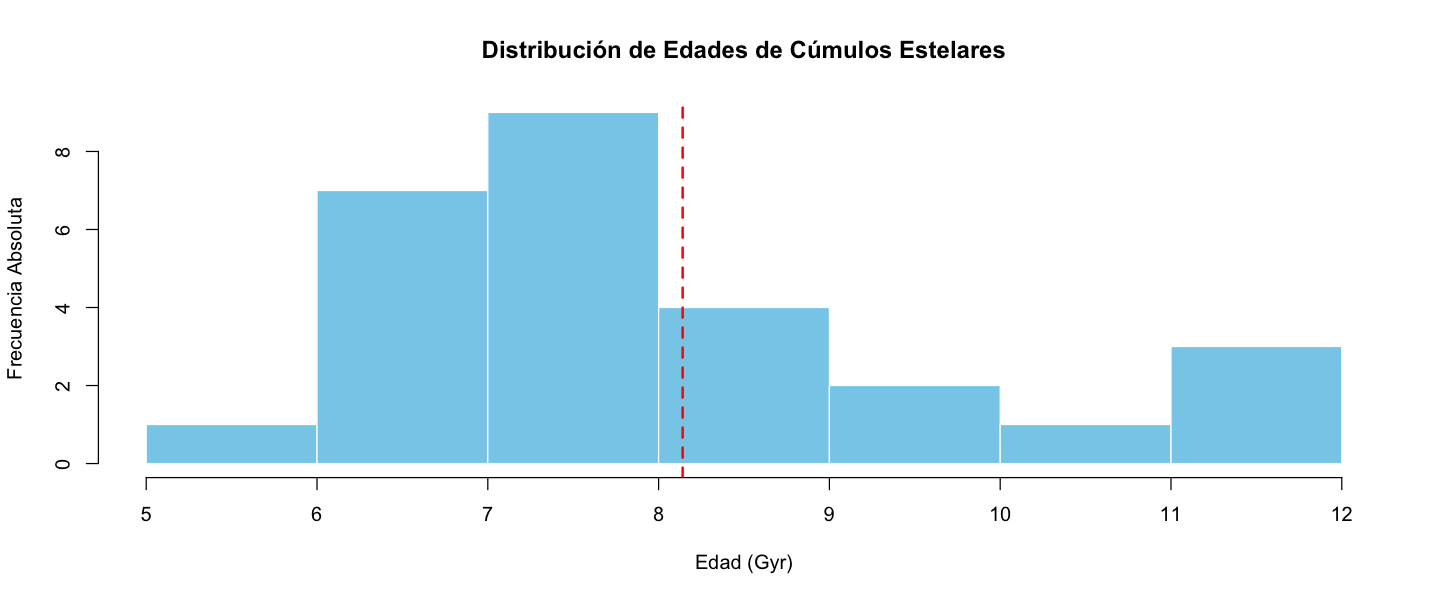

In [8]:
# Gráfico 1: Histograma de Frecuencias
hist(edades, 
     main = "Distribución de Edades de Cúmulos Estelares",
     xlab = "Edad (Gyr)", 
     ylab = "Frecuencia Absoluta", 
     col = "skyblue", 
     border = "white",
     breaks = 6) # Sugiere el número de barras
abline(v = media_edad, col = "red", lwd = 2, lty = 2) # Línea punteada de la media

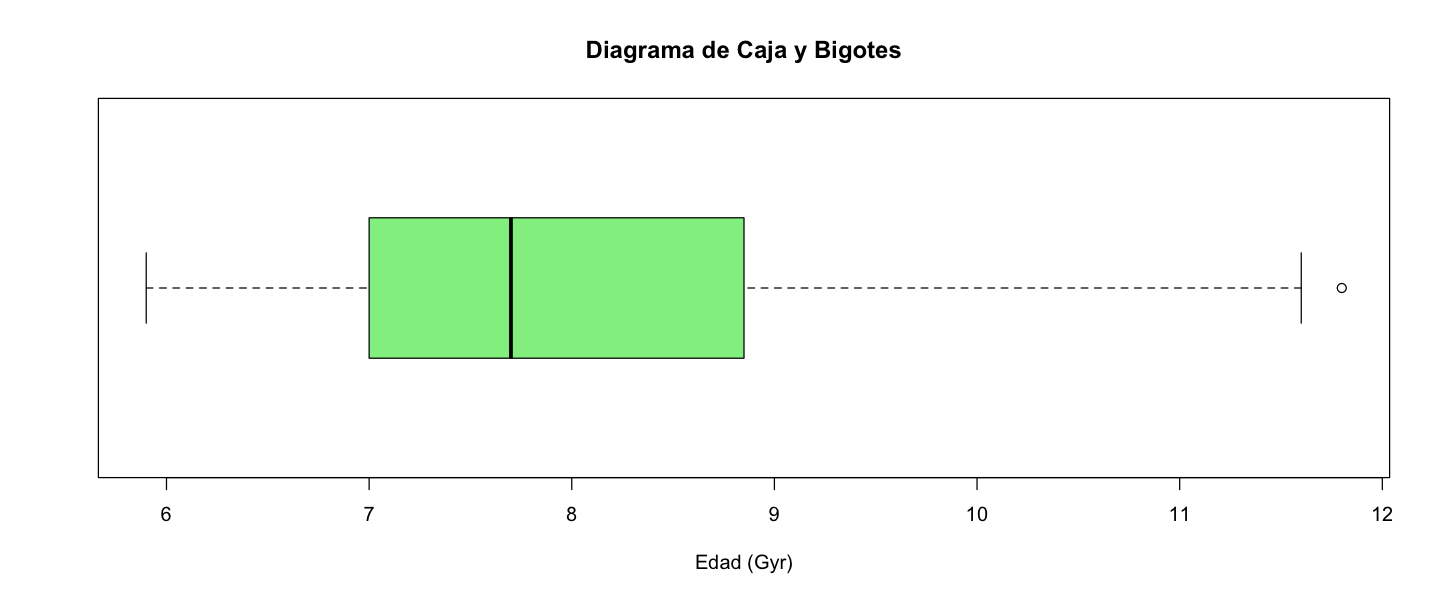

In [11]:
# Gráfico 2: Diagrama de Caja (Boxplot) para detectar dispersión y valores atípicos
boxplot(edades, 
        main = "Diagrama de Caja y Bigotes",
        xlab = "Edad (Gyr)", 
        col = "lightgreen",
        horizontal = TRUE)

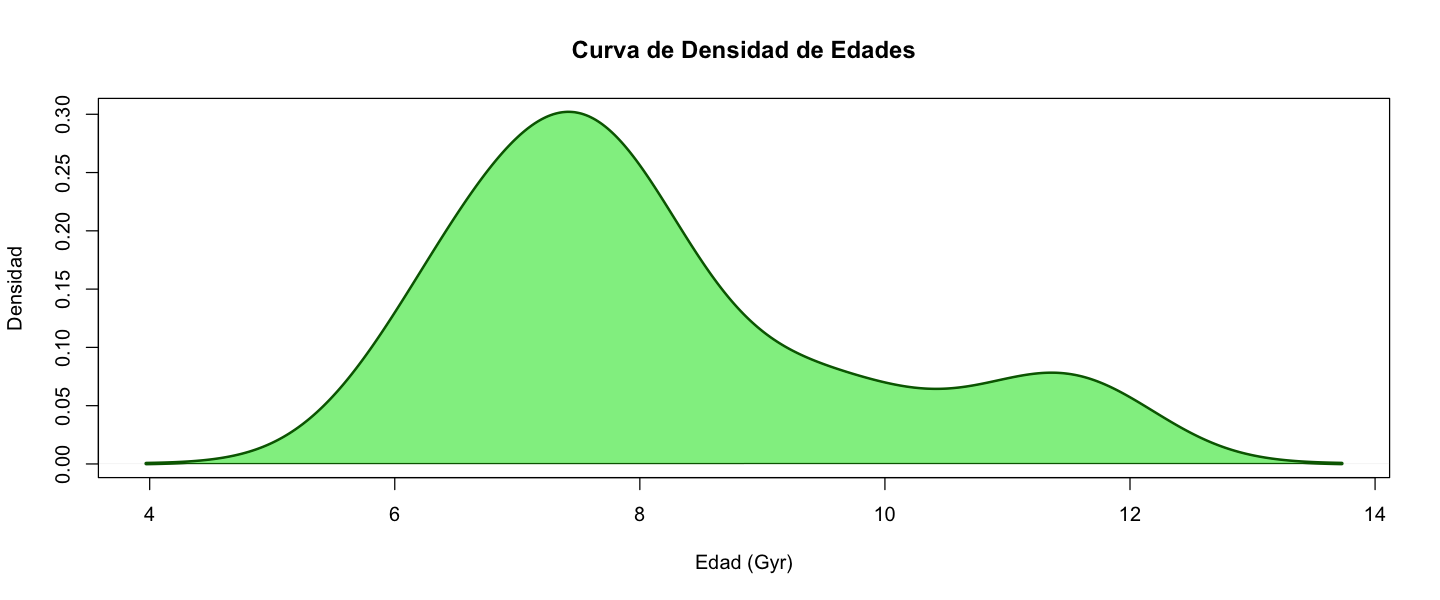

In [21]:
plot(density(edades), 
     main = "Curva de Densidad de Edades", 
     xlab = "Edad (Gyr)", 
     ylab = "Densidad", 
     col = "darkgreen", 
     lwd = 3) # lwd cambia el grosor de la línea

# Opcional: Rellena el área bajo la curva con tu color claro
polygon(density(edades), col = "lightgreen", border = "darkgreen")

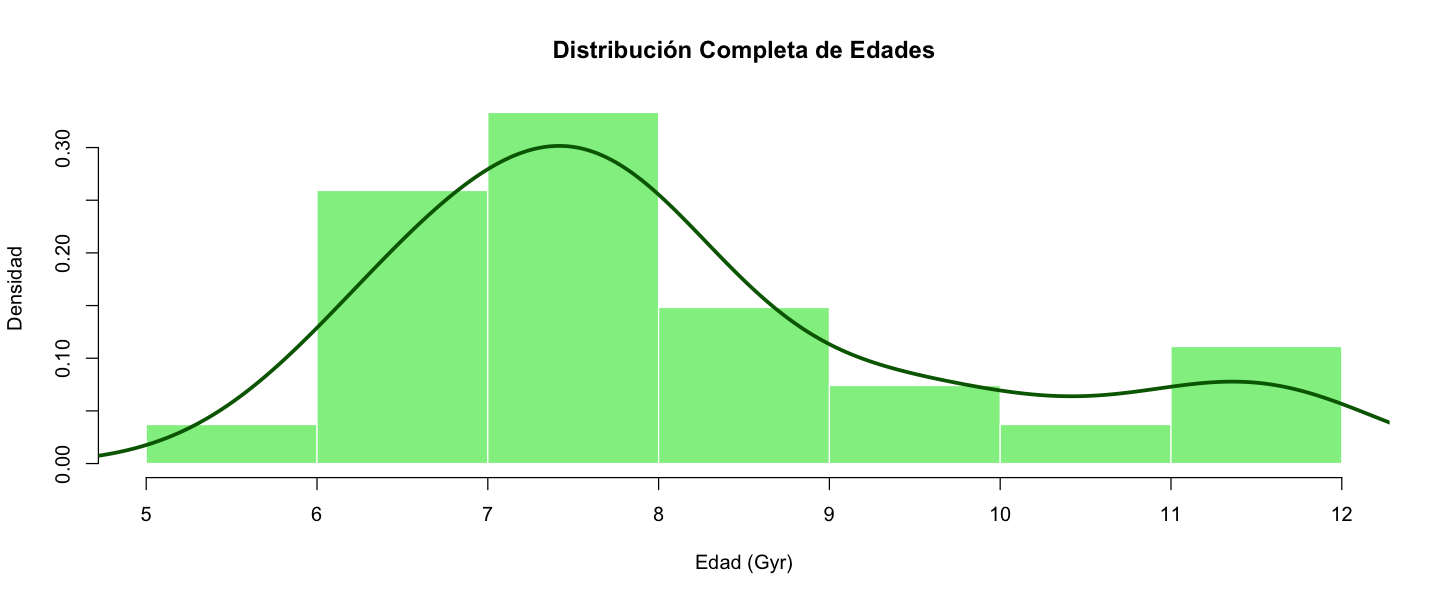

In [22]:
# hist con prob=TRUE para que la escala sea compatible con la densidad
hist(edades, prob = TRUE, main = "Distribución Completa de Edades", 
     xlab = "Edad (Gyr)", ylab = "Densidad", col = "lightgreen", border = "white")

# Añade la línea encima
lines(density(edades), col = "darkgreen", lwd = 3)

In [12]:
summary(edades)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  5.900   7.000   7.700   8.141   8.850  11.800 

In [16]:
library(psych)

In [20]:
describe(edades)

,vars,n,mean,sd,median,trimmed,mad,min,max,range,skew,kurtosis,se
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
X1,1,27,8.140741,1.659532,7.7,8.008696,1.33434,5.9,11.8,5.9,0.882432,-0.3410638,0.319377


In [19]:
print(describe(edades), digits = 2)

   vars  n mean   sd median trimmed  mad min  max range skew kurtosis   se
X1    1 27 8.14 1.66    7.7    8.01 1.33 5.9 11.8   5.9 0.88    -0.34 0.32


In [26]:
library(ggplot2)


Attaching package: ‘ggplot2’


The following objects are masked from ‘package:psych’:

    %+%, alpha




In [27]:
# Asegúrate de tener tus datos guardados en un Data Frame para ggplot2
df_edades <- data.frame(edades = c(
  9.7,  7.7,  7.4,  9.7,  7.8, 11.8,  8.2,
 11.3,  8.7,  6.8,  5.9,  7.2,  7.3,  6.3,
  9.0,  7.9,  6.3,  7.6, 10.7,  6.5,  7.0,
  8.1,  6.8,  7.0,  7.8,  7.7, 11.6
))

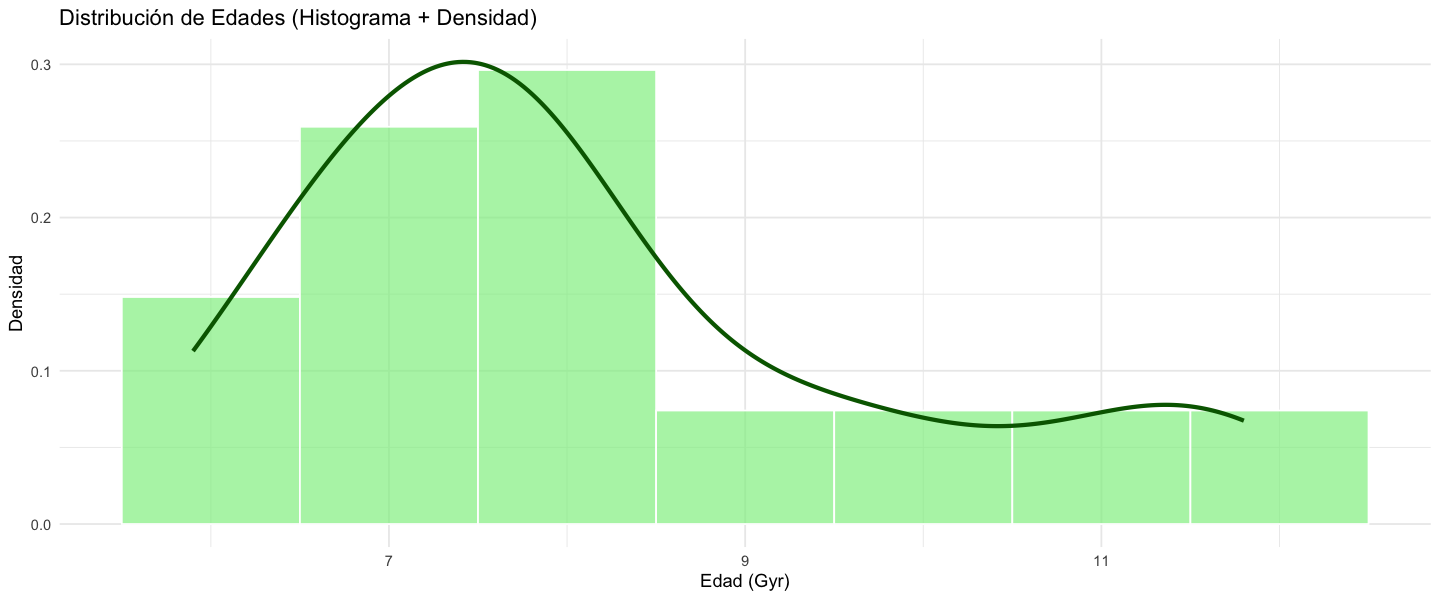

In [28]:
# Ejecutar el gráfico integrado
ggplot(df_edades, aes(x = edades)) +
  geom_histogram(aes(y = after_stat(density)), binwidth = 1, fill = "lightgreen", color = "white", alpha = 0.7) +
  geom_density(color = "darkgreen", linewidth = 1.2) +
  labs(title = "Distribución de Edades (Histograma + Densidad)",
       x = "Edad (Gyr)",
       y = "Densidad") +
  theme_minimal()